# FMATCH 2/10 — Ancillary reader framework & gridded readers

**PR topic**: the plugin architecture that turns heterogeneous external datasets into
one uniform spatial object — the `GridTile` — plus the six *gridded* ancillary readers.

The whole point of a reader is a **before → after** transform: an external file in its
own native format, projection, and axis conventions goes *in*; a small
`(data, lats, lons, bounds)` tile on a regular lat/lon grid comes *out*. Everything
downstream (tile manager, PSF aggregation) only ever sees the "after" side, so it never
needs to know that ERA5 stores latitude descending or that NISE lives on a polar grid.

The six readers fall into two families by *how* they do that transform:

| family | readers | native grid | transform |
|---|---|---|---|
| **direct-slice** | `era5`, `era5_pressure`, `viirs_aod`, `viirs_brdf` | regular lat/lon | normalize axes, then slice the tile window |
| **reproject + rasterize** | `igbp`, `nise` | projected (sinusoidal / EASE-Grid) | reproject pixel centers to lat/lon, then bin the point cloud onto a grid |

| reader key | dataset | format |
|---|---|---|
| `era5` | [ERA5 single-level reanalysis](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels) (winds + 5 IMAGER fields) | [NetCDF4](https://www.unidata.ucar.edu/software/netcdf/) |
| `era5_pressure` | [ERA5 pressure-level fields](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels) (37 levels) | NetCDF4 |
| `igbp` | [IGBP land cover](https://lpdaac.usgs.gov/products/mcd12q1v061/) (MODIS, [sinusoidal grid](https://modis-land.gsfc.nasa.gov/MODLAND_grid.html)) | [HDF4](https://www.hdfgroup.org/solutions/hdf4/) |
| `nise` | [NSIDC NISE snow/ice](https://nsidc.org/data/nise/versions/5) ([EASE-Grid](https://nsidc.org/data/user-resources/help-center/guide-ease-grids), both hemispheres) | [HDF-EOS4](https://www.hdfeos.org/) |
| `viirs_aod` | [VIIRS Deep Blue aerosol](https://ladsweb.modaps.eosdis.nasa.gov/missions-and-measurements/products/AERDB_D3_VIIRS_NOAA20) (AERDB_D3_VIIRS_NOAA20) | NetCDF4 |
| `viirs_brdf` | [VIIRS BRDF](https://lpdaac.usgs.gov/products/vj143c1v002/) (VJ143C1) | [HDF-EOS5](https://www.hdfeos.org/) |

The swath-product readers (CERES SSF, CLDPIX, VIIRS cloud) arrive in the **next PR**.

**Architecture in one paragraph**: every reader subclasses `GriddedDataReader` and
declares `READER_KEY`, `INSTRUMENT`, `RESOLUTION_KM`, and a `VARIABLES` tuple of
`VariableSpec`s. Subclassing auto-registers the reader in `ReaderRegistry`
([`__init_subclass__`](https://docs.python.org/3/reference/datamodel.html#object.__init_subclass__) hook) — no central list to maintain. `load_tile(TileKey)` is a
[template method](https://en.wikipedia.org/wiki/Template_method_pattern): it converts the tile key to a lat/lon `BoundingBox` and delegates to
the subclass's `_load_spatial_region`. The heavy geospatial stack ([`pyproj`](https://pyproj4.github.io/pyproj/stable/), [`pyhdf`](https://fhs.github.io/pyhdf/),
[`h5py`](https://docs.h5py.org/en/stable/)) is behind the optional [`fmatch` extra](https://python-poetry.org/docs/pyproject/#extras) and imported lazily, so a core-only
install still imports cleanly.

In [1]:
import sys
import tempfile
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# Notebook lives in notebooks/; the synthetic-fixture generators live in tests/.
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
import libera_utils.footprint_matching.readers  # noqa: F401  (import triggers registration)
from libera_utils.footprint_matching.readers.registry import ReaderRegistry
from libera_utils.footprint_matching.types import BoundingBox, TileKey

workdir = Path(tempfile.mkdtemp(prefix="fmatch_nb02_"))

## 1. The registry: readers self-register on import

Importing the `readers` package defines every reader class, and defining a
`GriddedDataReader` subclass registers it. Downstream code never imports concrete
readers — it asks the registry by key.

In [3]:
print(ReaderRegistry.list_readers())

['era5', 'era5_pressure', 'igbp', 'nise', 'viirs_aod', 'viirs_brdf']


## 2. The read/product contract per reader

`VARIABLES` is what a reader reads from its file; `product_variable_specs()` is what
it contributes to the FMATCH product definition — the read variables plus
automatically-inserted `_standard_deviation` companions for continuous fields plus
derived outputs (e.g. IGBP's ranked scene types). One method keeps readers, YAMLs,
and tests agreeing on the exact names.

In [4]:
rows = []
for key in ReaderRegistry.list_readers():
    reader_cls = ReaderRegistry.get(key)
    rows.append(
        {
            "reader": key,
            "instrument": reader_cls.INSTRUMENT,
            "resolution_km": reader_cls.RESOLUTION_KM,
            "read_vars": len(reader_cls.VARIABLES),
            "product_vars": len(reader_cls.product_variable_specs()),
        }
    )
pd.DataFrame(rows).set_index("reader")

,instrument,resolution_km,read_vars,product_vars
reader,,,,
era5,ECMWF,25.0,7,14
era5_pressure,ECMWF,25.0,185,370
igbp,MODIS,1.0,1,4
nise,SSMIS,25.0,5,10
viirs_aod,NOAA20,111.0,2,6
viirs_brdf,NOAA20,5.6,9,18


## 3. Family A — direct-slice readers (regular lat/lon grids)

These four datasets already live on a regular lat/lon grid, so the reader's job is to
**normalize axis conventions** (longitude wrapping, latitude direction, extra
dimensions) and then **slice** the requested tile window. No reprojection is involved.
We look at each one as *raw file in* → *`GridTile` out*.

### 3a. ERA5 single-level (NetCDF4)

**Native structure** — a [CDS](https://cds.climate.copernicus.eu/) NetCDF4 file with the
seven single-level fields as **top-level variables** (no groups) on a global lat/lon grid.
Two conventions the reader must fix: latitude is stored [**descending**](https://confluence.ecmwf.int/display/CKB/ERA5%3A+data+documentation)
(90 → −90), and longitude may be 0–360 instead of −180–180. A leading `time` /
`valid_time` dimension carries the snapshot.

**Reader transform** (`era5.py`, direct slice): open with the `netcdf4` engine → remap
longitudes to −180–180 and sort → keep the first time step → flip latitude to *ascending*
→ `np.stack` the 7 variables onto axis 0 in `VARIABLES` order → boolean-mask the tile's
lat/lon window.

In [5]:
from tests.test_data.footprint_matching.fixtures import make_era5_netcdf_fixture

era5_path = make_era5_netcdf_fixture(workdir, lat_min=0.0, lat_max=8.0, lon_min=10.0, lon_max=18.0, n_lat=33, n_lon=33)

# The fixture's winds are constant (tuned for exact-value unit tests) and would plot as a
# flat color; overwrite u10/v10 with smooth fields, computed from the file's own
# (descending) coordinates, so the "after" plot shows structure. The reader is unchanged.
with xr.open_dataset(era5_path) as _ds:
    ds_raw = _ds.load()
lat2d, lon2d = np.meshgrid(ds_raw["latitude"].values, ds_raw["longitude"].values, indexing="ij")
ds_raw["u10"].values[:] = (6.0 * np.sin(2 * np.pi * lat2d / 3.0 + 2 * np.pi * lon2d / 6.0)).astype("float32")
ds_raw["v10"].values[:] = (6.0 * np.cos(2 * np.pi * lat2d / 4.0 - 2 * np.pi * lon2d / 3.0)).astype("float32")
era5_path = workdir / "era5_smooth.nc"
ds_raw.to_netcdf(era5_path)

print("BEFORE — raw NetCDF file (note: 7 top-level variables, latitude DESCENDING):")
print(ds_raw)

BEFORE — raw NetCDF file (note: 7 top-level variables, latitude DESCENDING):
<xarray.Dataset> Size: 31kB
Dimensions:    (latitude: 33, longitude: 33)
Coordinates:
  * latitude   (latitude) float64 264B 8.0 7.75 7.5 7.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 264B 10.0 10.25 10.5 ... 17.5 17.75 18.0
Data variables:
    u10        (latitude, longitude) float32 4kB 5.196 4.243 ... -4.409e-15
    v10        (latitude, longitude) float32 4kB -3.0 -5.196 -6.0 ... 5.196 6.0
    t2m        (latitude, longitude) float32 4kB 285.0 285.0 ... 285.0 285.0
    d2m        (latitude, longitude) float32 4kB 280.0 280.0 ... 280.0 280.0
    sp         (latitude, longitude) float32 4kB 1.013e+05 ... 1.013e+05
    z          (latitude, longitude) float32 4kB 500.0 500.0 ... 500.0 500.0
    fal        (latitude, longitude) float32 4kB 0.3 0.3 0.3 0.3 ... 0.3 0.3 0.3


The reader returns a `GridTile`: the seven variables stacked on axis 0, latitude
flipped ascending, and sliced to the requested 2°×2° window. `TileKey(source, lat_idx,
lon_idx)` indexes the global 2° grid (`lat_idx = (lat + 90) / 2`,
`lon_idx = (lon + 180) / 2`).

In [6]:
era5 = ReaderRegistry.get("era5")(era5_path)
tile = era5.load_tile(TileKey("era5", lat_idx=46, lon_idx=96))  # lat [2,4], lon [12,14]

print("AFTER — GridTile:")
print(f"  data.shape = {tile.data.shape}   (variables, lat, lon), variables in VARIABLES order")
print(f"  lats       = {tile.lats[0]}..{tile.lats[-1]}   ascending={bool(tile.lats[0] < tile.lats[-1])}")
print(f"  bounds     = {tile.bounds}")
print(f"  source     = {tile.source!r}")

AFTER — GridTile:
  data.shape = (7, 9, 9)   (variables, lat, lon), variables in VARIABLES order
  lats       = 2.0..4.0   ascending=True
  bounds     = BoundingBox(lat=[2.0, 4.0], lon=[12.0, 14.0], wraps_dateline=False, is_polar=False, truncated=False)
  source     = 'era5'


The two 10 m wind components (`data[0]` and `data[1]`) over the tile — the smooth
fields injected above, on a symmetric diverging scale:

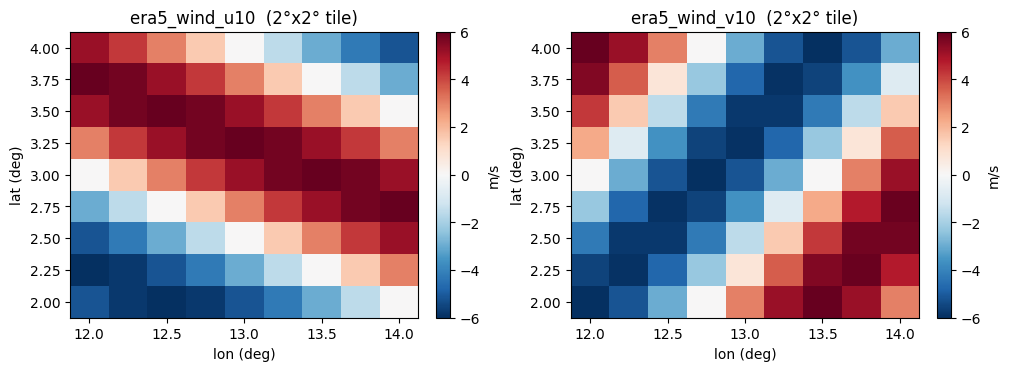

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
for ax, var_idx in zip(axes, (0, 1), strict=True):
    vmax = float(np.nanmax(np.abs(tile.data[var_idx])))
    im = ax.pcolormesh(tile.lons, tile.lats, tile.data[var_idx], shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"era5_{era5.VARIABLES[var_idx].name}  (2°x2° tile)")
    ax.set_xlabel("lon (deg)")
    ax.set_ylabel("lat (deg)")
    fig.colorbar(im, ax=ax, label="m/s")
plt.show()

### 3b. ERA5 pressure-level (NetCDF4) — the level axis is flattened

Same conventions as single-level, **plus a `pressure_level` dimension** (37 hPa levels).
Five variables (`t`, `z`, `o3`, `q`, `r`) each span all 37 levels. The reader does not
keep a 4-D array: it selects each level *by value* (not position) and flattens
**variable-major** into 185 = 5 × 37 planes on axis 0, named
`temperature_1hPa … relative_humidity_1000hPa`, so every plane is a single 2-D field the
aggregation stage can treat exactly like any other.

In [8]:
from tests.test_data.footprint_matching.fixtures import make_era5_pressure_netcdf_fixture

pres_path = make_era5_pressure_netcdf_fixture(
    workdir, lat_min=0.0, lat_max=8.0, lon_min=10.0, lon_max=18.0, n_lat=33, n_lon=33
)
with xr.open_dataset(pres_path) as _p:
    print("BEFORE — raw dims:", dict(_p.sizes))
    print("BEFORE — data variables (each spans 37 levels):", list(_p.data_vars))

pres = ReaderRegistry.get("era5_pressure")(pres_path)
ptile = pres.load_tile(TileKey("era5_pressure", 46, 96))
print(f"\nAFTER — GridTile data.shape = {ptile.data.shape}   (5 vars x 37 levels = 185 planes)")
print("first planes:", [v.name for v in pres.VARIABLES[:2]], "... last:", [v.name for v in pres.VARIABLES[-2:]])

BEFORE — raw dims: {'valid_time': 1, 'pressure_level': 37, 'latitude': 33, 'longitude': 33}
BEFORE — data variables (each spans 37 levels): ['t', 'z', 'o3', 'q', 'r']



AFTER — GridTile data.shape = (185, 9, 9)   (5 vars x 37 levels = 185 planes)
first planes: ['temperature_1hPa', 'temperature_2hPa'] ... last: ['relative_humidity_975hPa', 'relative_humidity_1000hPa']


### 3c. VIIRS AOD (NetCDF4) and BRDF (HDF-EOS5) — same tile, different file shapes

Both are direct-slice readers, but their files could not look more different, which is the
point of the uniform `GridTile`:

- **AOD** (`AERDB_D3_VIIRS_NOAA20`): flat NetCDF4, variables at the **root** on a 1° grid,
  latitude ascending, fill value −999. The reader reads two fields — `aod_550`
  (continuous, [`weighted_log_mean`](https://en.wikipedia.org/wiki/Geometric_mean)) and
  `aerosol_type` (categorical, `weighted_mode`) — masking fills to NaN.
- **BRDF** (`VJ143C1`): HDF-EOS5, data buried in a **group hierarchy**
  `HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields`, stored as **`int16` with `scale_factor`
  = 0.001** and fill 32767, latitude descending. The reader reads nine kernel-weight
  datasets, scales them to float, stacks on axis 0, and flips latitude.

In [9]:
from tests.test_data.footprint_matching.fixtures import make_aod_noaa20_fixture

aod_path = make_aod_noaa20_fixture(workdir, n_lat=16, n_lon=16, lat_min=0.5, lat_max=7.5, lon_min=10.5, lon_max=17.5)
with xr.open_dataset(aod_path) as _a:
    print("AOD BEFORE — root variables:", list(_a.data_vars))
    print("AOD BEFORE — dims:", dict(_a.sizes), "(Aerosol_Types axis belongs to the unread histogram)")
aod = ReaderRegistry.get("viirs_aod")(aod_path)
aod_tile = aod.load_tile(TileKey("viirs_aod", 46, 96))
print(
    f"AOD AFTER  — tile.data.shape={aod_tile.data.shape}  axis0=[aod_550, aerosol_type]  "
    f"aod_550 mean={np.nanmean(aod_tile.data[0]):.3f}"
)

AOD BEFORE — root variables: ['Aerosol_Optical_Thickness_550_Land_Ocean_Mean', 'Aerosol_Type_Land_Ocean_Mode', 'Aerosol_Type_Land_Ocean_Histogram']
AOD BEFORE — dims: {'Latitude_1D': 16, 'Longitude_1D': 16, 'Aerosol_Types': 8} (Aerosol_Types axis belongs to the unread histogram)
AOD AFTER  — tile.data.shape=(2, 4, 4)  axis0=[aod_550, aerosol_type]  aod_550 mean=0.200


In [10]:
from tests.test_data.footprint_matching.fixtures import make_viirs_brdf_hdf5_fixture

brdf_path = make_viirs_brdf_hdf5_fixture(
    workdir, n_lat=40, n_lon=40, lat_min=2.0, lat_max=4.0, lon_min=12.0, lon_max=14.0
)

# The fixture writes constant int16 counts (200 -> 0.200); overwrite the nine parameter
# datasets with smooth int16 gradients so the scaled "after" plot shows structure and
# makes the int16 -> float scale_factor step visible. The fill sentinel (32767) is kept.
_grp = "HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields"
with h5py.File(brdf_path, "r+") as f:
    blat = f[f"{_grp}/lat"][:]
    blon = f[f"{_grp}/lon"][:]
    bl2d, bo2d = np.meshgrid(blat, blon, indexing="ij")
    for i, name in enumerate(k for k in f[_grp] if k.startswith("BRDF_Albedo_Parameter")):
        field = 0.18 + 0.10 * np.sin(bl2d * 2.0 + i) * np.cos(bo2d * 1.5)  # reflectance 0.08..0.28
        counts = np.clip(field / 0.001, 0, 32000).astype("int16")  # scale_factor = 0.001
        counts[-1, -1] = 32767  # keep one fill sentinel
        f[f"{_grp}/{name}"][:] = counts

print("BRDF BEFORE — HDF-EOS5 group hierarchy (int16 datasets nested under GRIDS):")
with h5py.File(brdf_path, "r") as f:

    def _show(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"    /{name}   {obj.shape} {obj.dtype}")

    f.visititems(_show)

brdf = ReaderRegistry.get("viirs_brdf")(brdf_path)
brdf_tile = brdf.load_tile(TileKey("viirs_brdf", 46, 96))
print(f"\nBRDF AFTER  — tile.data.shape={brdf_tile.data.shape} (9 kernel params, int16 -> float via scale_factor)")

BRDF BEFORE — HDF-EOS5 group hierarchy (int16 datasets nested under GRIDS):
    /HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields/BRDF_Albedo_Parameter1_nir   (40, 40) int16
    /HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields/BRDF_Albedo_Parameter1_shortwave   (40, 40) int16
    /HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields/BRDF_Albedo_Parameter1_vis   (40, 40) int16
    /HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields/BRDF_Albedo_Parameter2_nir   (40, 40) int16
    /HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields/BRDF_Albedo_Parameter2_shortwave   (40, 40) int16
    /HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields/BRDF_Albedo_Parameter2_vis   (40, 40) int16
    /HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields/BRDF_Albedo_Parameter3_nir   (40, 40) int16
    /HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields/BRDF_Albedo_Parameter3_shortwave   (40, 40) int16
    /HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields/BRDF_Albedo_Parameter3_vis   (40, 40) int16
    /HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields/lat   (40,) float64
    /HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fi

The BRDF "after" — one scaled kernel-weight plane on the regular tile grid (the raw
`int16` counts are now physical reflectance parameters):

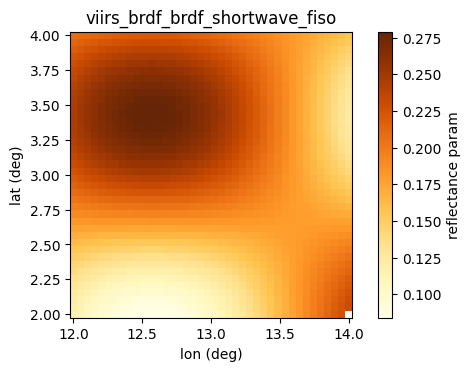

In [11]:
fig, ax = plt.subplots(figsize=(4.6, 3.6), constrained_layout=True)
name = brdf.VARIABLES[0].name
im = ax.pcolormesh(brdf_tile.lons, brdf_tile.lats, brdf_tile.data[0], shading="auto", cmap="YlOrBr")
ax.set_title(f"viirs_brdf_{name}")
ax.set_xlabel("lon (deg)")
ax.set_ylabel("lat (deg)")
fig.colorbar(im, ax=ax, label="reflectance param")
plt.show()

## 4. Family B — reproject + rasterize readers (projected grids)

IGBP and NISE do **not** live on a lat/lon grid, so they cannot be sliced directly. Their
native pixels sit on a map projection; the reader computes each pixel's true lat/lon,
turning the image into a **point cloud**, and then bins that cloud onto the tile grid with
the shared `rasterize_points_to_grid` helper (from `_swath.py`). Writing real HDF4 needs
the HDF4 C library, so — exactly as the unit tests do — we feed synthetic native arrays
through the readers' HDF-read seam and let the real reprojection + rasterization code run.

### 4a. IGBP land cover — MODIS sinusoidal → lat/lon

**Native structure**: HDF4 MCD12Q1 tiles on the [MODIS sinusoidal projection](https://modis-land.gsfc.nasa.gov/MODLAND_grid.html).
Latitude/longitude are *not* stored — they are derived from the tile's corner metadata, so
every pixel has its own (curved) lat/lon. The land-cover code SDS is `uint8` with fill 255
and valid IGBP classes 1–17.

**Reader transform**: `read_modis_sinusoidal_hdf4` returns `(codes, lats_2d, lons_2d)`; the
reader masks out-of-range codes to NaN, ravels to a point cloud, and
`rasterize_points_to_grid` bins the points onto 0.05° cells using `weighted_mode` (the most
common class wins each cell). The single-variable output is squeezed to a 2-D tile.

In [12]:
import libera_utils.footprint_matching.readers.igbp as igbp_mod

# Synthetic native sinusoidal pixel block (stand-in for the HDF4 read): per-pixel lat/lon
# with a mild shear so the "before" points are visibly NOT axis-aligned, and blocky IGBP
# land-cover codes (1..17; 255 = fill). The native grid is finer than the 0.05° output
# cells so the rasterized tile fills without gaps.
nlat = nlon = 100
_latn = np.linspace(4.6, 1.4, nlat)  # native rows, descending like a real tile
_lonn = np.linspace(11.4, 14.6, nlon)
ig_lon2d, ig_lat2d = np.meshgrid(_lonn, _latn)
ig_lon2d = ig_lon2d + 0.15 * np.sin(ig_lat2d - 3.0)  # evoke sinusoidal curvature
ig_codes = np.full((nlat, nlon), 10, dtype=np.int16)  # 10 = grassland
ig_codes[ig_lat2d > 3.2] = 4  # 4 = deciduous broadleaf forest
ig_codes[ig_lon2d > 13.3] = 17  # 17 = water
ig_codes[(ig_lat2d < 2.3) & (ig_lon2d < 12.6)] = 13  # 13 = urban
ig_codes[0, 0] = 255  # a fill pixel (dropped by the reader)

igbp_mod.read_modis_sinusoidal_hdf4 = lambda **kw: (ig_codes.copy(), ig_lat2d.copy(), ig_lon2d.copy())

igbp_dummy = workdir / "igbp_dummy.hdf"
igbp_dummy.write_bytes(b"")  # path only; the HDF4 read is stubbed above
igbp = ReaderRegistry.get("igbp")(igbp_dummy)
igbp_tile = igbp.load_tile(TileKey("igbp", 46, 96))  # lat [2,4], lon [12,14]
print(f"BEFORE — native pixels: {ig_codes.size}   AFTER — rasterized tile.data.shape={igbp_tile.data.shape} (2-D)")

BEFORE — native pixels: 10000   AFTER — rasterized tile.data.shape=(40, 40) (2-D)


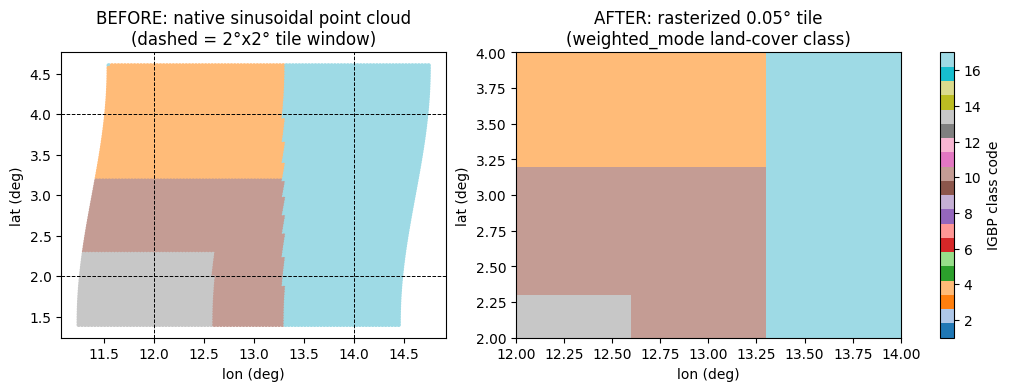

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
sc = axes[0].scatter(ig_lon2d, ig_lat2d, c=ig_codes, cmap="tab20", vmin=1, vmax=17, s=5)
axes[0].axhline(2, color="k", lw=0.7, ls="--")
axes[0].axhline(4, color="k", lw=0.7, ls="--")
axes[0].axvline(12, color="k", lw=0.7, ls="--")
axes[0].axvline(14, color="k", lw=0.7, ls="--")
axes[0].set_title("BEFORE: native sinusoidal point cloud\n(dashed = 2°x2° tile window)")
axes[0].set_xlabel("lon (deg)")
axes[0].set_ylabel("lat (deg)")
im = axes[1].pcolormesh(igbp_tile.lons, igbp_tile.lats, igbp_tile.data, cmap="tab20", vmin=1, vmax=17, shading="auto")
axes[1].set_title("AFTER: rasterized 0.05° tile\n(weighted_mode land-cover class)")
axes[1].set_xlabel("lon (deg)")
axes[1].set_ylabel("lat (deg)")
fig.colorbar(im, ax=axes[1], label="IGBP class code")
plt.show()

### 4b. NISE snow/ice — EASE-Grid (both hemispheres) → lat/lon

**Native structure**: HDF-EOS4, two 721×721 [EASE-Grid](https://nsidc.org/data/user-resources/help-center/guide-ease-grids)
polar grids in one granule — Northern ([EPSG:3408](https://epsg.io/3408)) and Southern
([EPSG:3409](https://epsg.io/3409)). A single `Extent` field (`uint8`) encodes everything:
0 = no ice/snow, 1–100 = sea-ice percent, 101 = permanent ice, 103–110 = dry snow,
254 = off-Earth corner, 255 = missing.

**Reader transform**: for each hemisphere it computes pixel centers, reprojects them to
WGS84 with [pyproj](https://pyproj4.github.io/pyproj/stable/), **splits the one Extent code
into five physical layers** (`sea_ice_concentration`, `no_ice_or_snow`, `permanent_ice`,
`dry_snow_on_land`, `snow_ice_missing`), drops the off-Earth corners, **concatenates both
hemispheres** into one point cloud, and rasterizes onto 0.25° cells. Below is a Northern
synthetic grid; note how the reprojected points fan out (the polar projection) before
being binned.

In [14]:
# Synthetic Northern EASE-Grid Extent block, placed off-pole so it lands on a compact
# mid-Arctic region. The reader's _read_extent_sds seam is stubbed (as the unit tests do);
# the real pyproj EPSG:3408 -> WGS84 reprojection and rasterization then run for real.
n = 64
nise = ReaderRegistry.get("nise")(
    workdir / "nise_dummy.hdfeos",
    grid_rows=n,
    grid_cols=n,
    resolution_m=15_000.0,
    x_origin=1_200_000.0,
    y_origin=1_200_000.0,
)
(workdir / "nise_dummy.hdfeos").write_bytes(b"")
extent = np.tile(np.linspace(20, 90, n).astype(np.uint8), (n, 1))  # sea-ice % ramp
extent[: n // 3, : n // 3] = 101  # permanent-ice corner
extent[2 * n // 3 :, 2 * n // 3 :] = 0  # open-water corner
nise._read_extent_sds = lambda token=None: extent

ni_lats, ni_lons, ni_vals = nise._load_points  # reprojected + split into 5 layers
bbox = BoundingBox(
    float(ni_lats.min()), float(ni_lats.max()), float(ni_lons.min()), float(ni_lons.max()), False, True, False
)
ni_data, ni_tlats, ni_tlons = nise._load_spatial_region(bbox)
print(f"BEFORE — native Extent {extent.shape} uint8   -> reprojected points: {ni_lats.size}")
print(f"AFTER  — rasterized tile.data.shape={ni_data.shape}  (5 layers, axis0={[v.name for v in nise.VARIABLES]})")

BEFORE — native Extent (64, 64) uint8   -> reprojected points: 4096
AFTER  — rasterized tile.data.shape=(5, 45, 152)  (5 layers, axis0=['sea_ice_concentration', 'no_ice_or_snow', 'permanent_ice', 'dry_snow_on_land', 'snow_ice_missing'])


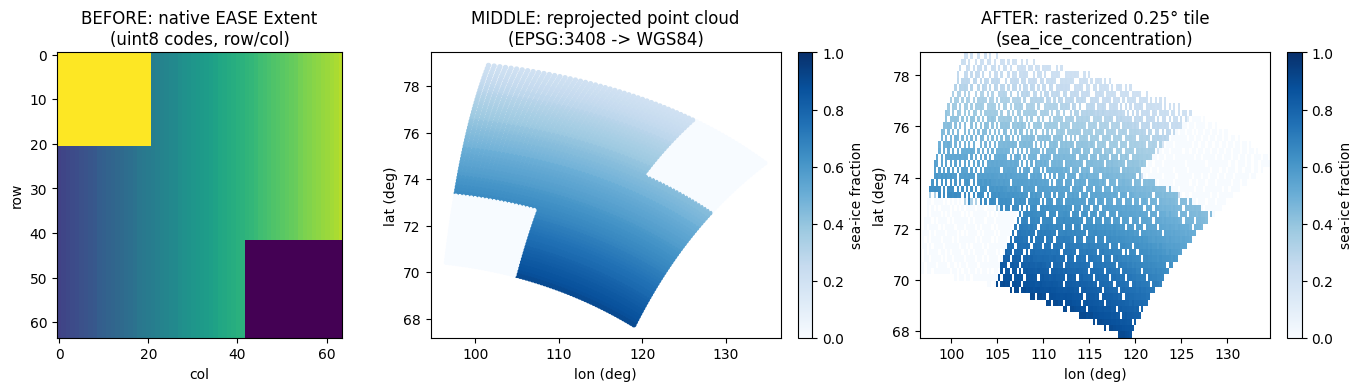

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
axes[0].imshow(extent, cmap="viridis")
axes[0].set_title("BEFORE: native EASE Extent\n(uint8 codes, row/col)")
axes[0].set_xlabel("col")
axes[0].set_ylabel("row")
sic = ni_vals[0]  # sea_ice_concentration layer (fraction)
sc = axes[1].scatter(ni_lons, ni_lats, c=sic, cmap="Blues", vmin=0, vmax=1, s=8)
axes[1].set_title("MIDDLE: reprojected point cloud\n(EPSG:3408 -> WGS84)")
axes[1].set_xlabel("lon (deg)")
axes[1].set_ylabel("lat (deg)")
fig.colorbar(sc, ax=axes[1], label="sea-ice fraction")
im = axes[2].pcolormesh(ni_tlons, ni_tlats, ni_data[0], cmap="Blues", vmin=0, vmax=1, shading="auto")
axes[2].set_title("AFTER: rasterized 0.25° tile\n(sea_ice_concentration)")
axes[2].set_xlabel("lon (deg)")
axes[2].set_ylabel("lat (deg)")
fig.colorbar(im, ax=axes[2], label="sea-ice fraction")
plt.show()

## Where this goes next in the stack

- **PR 3** adds the swath readers (CERES SSF, CLDPIX, VIIRS cloud) and the final
  registry with all nine readers.
- **PR 4** adds the `TileManager`, which owns *which* `TileKey`s to request for a
  footprint `BoundingBox` (from PR 1) and caches the resulting `GridTile`s.
- The `VariableSpec` contracts shown above become the FMATCH product definitions in
  **PR 6**.